# 🧠 CBIS-DDSM - CNN Training with Transfer Learning

## Mục tiêu
- Build CNN models for mammogram classification
- Transfer learning: ResNet50, EfficientNetB0
- Custom architectures if needed
- Training with callbacks (early stopping, checkpoint)
- Model evaluation on validation set
- Save best models

## 🎯 Why Transfer Learning?

**Benefits:**
- ✅ Pre-trained on ImageNet (general visual features)
- ✅ Faster convergence
- ✅ Better performance with limited data
- ✅ Reduced risk of overfitting

**Models:**
1. **ResNet50**: Deep residual learning, 50 layers
2. **EfficientNetB0**: Compound scaling, efficient architecture
3. **Custom CNN**: Built from scratch for comparison

In [1]:
# Import libraries
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)

# Sklearn
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score
)

# Custom imports
from src.utils.config import *
from src.utils.helpers import *

# Set random seed
set_seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("✅ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

🎲 Random seed set to: 42
✅ Libraries imported successfully
TensorFlow version: 2.21.0
GPU available: []


## 1. Check Data Availability

In [2]:
# Define paths
CBIS_DATA_DIR = PROJECT_ROOT / 'data' / 'cbis_ddsm'
CBIS_IMAGES_DIR = CBIS_DATA_DIR / 'processed' / 'images'

TRAIN_DIR = CBIS_IMAGES_DIR / 'train'
VAL_DIR = CBIS_IMAGES_DIR / 'val'
TEST_DIR = CBIS_IMAGES_DIR / 'test'

# Create model directory for DL models
DL_MODEL_DIR = PROJECT_ROOT / 'models' / 'deep_learning'
DL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("📁 Data directories:")
print(f"  Train: {TRAIN_DIR}")
print(f"  Val:   {VAL_DIR}")
print(f"  Test:  {TEST_DIR}")

# Check if data exists
train_exists = TRAIN_DIR.exists()
val_exists = VAL_DIR.exists()
test_exists = TEST_DIR.exists()

if train_exists and val_exists and test_exists:
    # Count images
    train_benign = len(list((TRAIN_DIR / 'benign').glob('*.png')))
    train_malignant = len(list((TRAIN_DIR / 'malignant').glob('*.png')))
    val_benign = len(list((VAL_DIR / 'benign').glob('*.png')))
    val_malignant = len(list((VAL_DIR / 'malignant').glob('*.png')))
    test_benign = len(list((TEST_DIR / 'benign').glob('*.png')))
    test_malignant = len(list((TEST_DIR / 'malignant').glob('*.png')))
    
    print(f"\n✅ Data found!")
    print(f"  Train: {train_benign} benign, {train_malignant} malignant")
    print(f"  Val:   {val_benign} benign, {val_malignant} malignant")
    print(f"  Test:  {test_benign} benign, {test_malignant} malignant")
    
    DATA_AVAILABLE = True
    total_train = train_benign + train_malignant
    total_val = val_benign + val_malignant
    total_test = test_benign + test_malignant
else:
    print("\n⚠️ Data not found!")
    print("Please run Notebook 08 first to download and prepare data.")
    DATA_AVAILABLE = False
    total_train, total_val, total_test = 0, 0, 0

📁 Data directories:
  Train: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/data/cbis_ddsm/processed/images/train
  Val:   /Users/GiangNguyenHuy/Documents/breast-cancer-ai/data/cbis_ddsm/processed/images/val
  Test:  /Users/GiangNguyenHuy/Documents/breast-cancer-ai/data/cbis_ddsm/processed/images/test

✅ Data found!
  Train: 1040 benign, 750 malignant
  Val:   223 benign, 160 malignant
  Test:  224 benign, 162 malignant


## 2. Data Generators with Augmentation

In [3]:
if DATA_AVAILABLE:
    print_section_header("DATA GENERATORS")
    
    # Image parameters
    IMG_HEIGHT = 224
    IMG_WIDTH = 224
    BATCH_SIZE = 16  # Adjust based on GPU memory
    
    # Training data generator with augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest',
        preprocessing_function=lambda x: tf.image.per_image_standardization(x).numpy() if hasattr(x, 'numpy') else x
    )
    
    # Validation/Test data generator (no augmentation)
    val_test_datagen = ImageDataGenerator(
        rescale=1./255
    )
    
    # Create generators
    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=True,
        seed=RANDOM_STATE,
        color_mode='rgb'  # Convert grayscale to RGB for pretrained models
    )
    
    val_generator = val_test_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False,
        color_mode='rgb'
    )
    
    test_generator = val_test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False,
        color_mode='rgb'
    )
    
    print(f"✅ Data generators created")
    print(f"  Train batches: {len(train_generator)}")
    print(f"  Val batches:   {len(val_generator)}")
    print(f"  Test batches:  {len(test_generator)}")
    print(f"  Image size: {IMG_HEIGHT}x{IMG_WIDTH}")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Class indices: {train_generator.class_indices}")
    
else:
    print("⚠️ Skipping data generators - data not available")


                                DATA GENERATORS                                 

Found 1790 images belonging to 2 classes.
Found 383 images belonging to 2 classes.
Found 386 images belonging to 2 classes.
✅ Data generators created
  Train batches: 112
  Val batches:   24
  Test batches:  25
  Image size: 224x224
  Batch size: 16
  Class indices: {'benign': 0, 'malignant': 1}


## 3. Build Models

### A. ResNet50 with Transfer Learning

In [6]:
def build_resnet50_model(input_shape=(224, 224, 3), trainable_base=False):
    """
    Build ResNet50 model with transfer learning
    
    Args:
        input_shape: Input image shape
        trainable_base: Whether to fine-tune base model
    
    Returns:
        Compiled Keras model
    """
    # Load pretrained ResNet50 (without top layers) with offline fallback
    try:
        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
        print("✅ Loaded ImageNet pretrained weights for ResNet50")
    except Exception as err:
        print(f"⚠️ Could not download pretrained weights ({err})")
        print("   Falling back to random initialization (weights=None)")
        base_model = ResNet50(
            weights=None,
            include_top=False,
            input_shape=input_shape
        )
    
    # Freeze base model
    base_model.trainable = trainable_base
    
    # Add custom classification head
    inputs = keras.Input(shape=input_shape)
    
    # Preprocess for ResNet50
    x = tf.keras.applications.resnet50.preprocess_input(inputs)
    
    # Base model
    x = base_model(x, training=False)
    
    # Custom head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    # Create model
    model = keras.Model(inputs, outputs, name='ResNet50_Mammogram')
    
    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model


if DATA_AVAILABLE:
    print_section_header("BUILD RESNET50 MODEL")
    
    resnet_model = build_resnet50_model(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        trainable_base=False
    )
    
    print("✅ ResNet50 model created")
    print(f"  Total params: {resnet_model.count_params():,}")
    print(f"  Trainable params: {sum([tf.size(w).numpy() for w in resnet_model.trainable_weights]):,}")
    
    resnet_model.summary()
else:
    print("⚠️ Skipping model building - data not available")


                              BUILD RESNET50 MODEL                              

⚠️ Could not download pretrained weights (URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5: None -- [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028))
   Falling back to random initialization (weights=None)
✅ ResNet50 model created
  Total params: 24,121,729
  Trainable params: 529,409


Model: "ResNet50_Mammogram"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,121,729 (92.02 MB)

 Trainable params: 529,409 (2.02 MB)

 Non-trainable params: 23,592,320 (90.00 MB)

### B. EfficientNetB0 with Transfer Learning

In [7]:
def build_efficientnet_model(input_shape=(224, 224, 3), trainable_base=False):
    """
    Build EfficientNetB0 model with transfer learning
    
    Args:
        input_shape: Input image shape
        trainable_base: Whether to fine-tune base model
    
    Returns:
        Compiled Keras model
    """
    # Load pretrained EfficientNetB0 with offline fallback
    try:
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
        print("✅ Loaded ImageNet pretrained weights for EfficientNetB0")
    except Exception as err:
        print(f"⚠️ Could not download pretrained weights ({err})")
        print("   Falling back to random initialization (weights=None)")
        base_model = EfficientNetB0(
            weights=None,
            include_top=False,
            input_shape=input_shape
        )
    
    # Freeze base model
    base_model.trainable = trainable_base
    
    # Add custom classification head
    inputs = keras.Input(shape=input_shape)
    
    # Preprocess for EfficientNet
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    
    # Base model
    x = base_model(x, training=False)
    
    # Custom head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    # Create model
    model = keras.Model(inputs, outputs, name='EfficientNetB0_Mammogram')
    
    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model


if DATA_AVAILABLE:
    print_section_header("BUILD EFFICIENTNET MODEL")
    
    efficientnet_model = build_efficientnet_model(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        trainable_base=False
    )
    
    print("✅ EfficientNetB0 model created")
    print(f"  Total params: {efficientnet_model.count_params():,}")
    print(f"  Trainable params: {sum([tf.size(w).numpy() for w in efficientnet_model.trainable_weights]):,}")
else:
    print("⚠️ Skipping model building - data not available")


                            BUILD EFFICIENTNET MODEL                            

⚠️ Could not download pretrained weights (URL fetch failure on https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5: None -- [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028))
   Falling back to random initialization (weights=None)
✅ EfficientNetB0 model created
  Total params: 4,219,300
  Trainable params: 166,913


### C. Custom CNN (From Scratch)

In [8]:
def build_custom_cnn(input_shape=(224, 224, 3)):
    """
    Build custom CNN from scratch
    
    Args:
        input_shape: Input image shape
    
    Returns:
        Compiled Keras model
    """
    model = keras.Sequential([
        # Input
        layers.Input(shape=input_shape),
        
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name='Custom_CNN_Mammogram')
    
    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model


if DATA_AVAILABLE:
    print_section_header("BUILD CUSTOM CNN")
    
    custom_cnn_model = build_custom_cnn(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    
    print("✅ Custom CNN model created")
    print(f"  Total params: {custom_cnn_model.count_params():,}")
else:
    print("⚠️ Skipping model building - data not available")


                                BUILD CUSTOM CNN                                

✅ Custom CNN model created
  Total params: 1,442,337


## 4. Training Callbacks

In [9]:
def get_callbacks(model_name, patience=10):
    """
    Get training callbacks
    
    Args:
        model_name: Name for saving checkpoints
        patience: Patience for early stopping
    
    Returns:
        List of callbacks
    """
    callbacks = [
        # Early stopping
        EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
            verbose=1
        ),
        
        # Model checkpoint
        ModelCheckpoint(
            filepath=str(DL_MODEL_DIR / f'{model_name}_best.keras'),
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        
        # Reduce learning rate on plateau
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        
        # CSV logger
        CSVLogger(
            filename=str(RESULTS_DIR / f'{model_name}_training_log.csv'),
            separator=',',
            append=False
        )
    ]
    
    return callbacks


print("✅ Callback functions defined")

✅ Callback functions defined


## 5. Train Models

### A. Train ResNet50

In [ ]:
if DATA_AVAILABLE:
    print_section_header("TRAIN RESNET50")
    
    # Calculate class weights for imbalanced data
    total_train_samples = total_train
    benign_count = train_benign
    malignant_count = train_malignant
    
    class_weight = {
        0: total_train_samples / (2 * benign_count),
        1: total_train_samples / (2 * malignant_count)
    }
    
    print(f"Class weights: {class_weight}")
    
    # Train
    EPOCHS = 30
    
    print(f"\n🚀 Training ResNet50 for {EPOCHS} epochs...")
    
    history_resnet = resnet_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        class_weight=class_weight,
        callbacks=get_callbacks('resnet50', patience=7),
        verbose=1
    )
    
    print("\n✅ ResNet50 training complete!")
    
else:
    print("⚠️ Skipping training - data not available")


                                 TRAIN RESNET50                                 

Class weights: {0: 0.8605769230769231, 1: 1.1933333333333334}

🚀 Training ResNet50 for 30 epochs...
Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.5045 - auc: 0.5202 - loss: 0.9248
Epoch 1: val_auc improved from None to 0.50000, saving model to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/models/deep_learning/resnet50_best.keras

Epoch 1: finished saving model to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/models/deep_learning/resnet50_best.keras
112/112 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.5006 - auc: 0.5184 - loss: 0.9001 - val_accuracy: 0.4178 - val_auc: 0.5000 - val_loss: 1.8464 - learning_rate: 1.0000e-04
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.5085 - auc: 0.5212 - loss: 0.8727
Epoch 2: val_auc improved from 0.50000 to 0.53589, saving model to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/models/deep_learning/resnet50_best.keras

### B. Train EfficientNetB0

In [10]:
if DATA_AVAILABLE:
    print_section_header("TRAIN EFFICIENTNETB0")
    
    print(f"\n🚀 Training EfficientNetB0 for {EPOCHS} epochs...")
    
    history_efficientnet = efficientnet_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        class_weight=class_weight,
        callbacks=get_callbacks('efficientnetb0', patience=7),
        verbose=1
    )
    
    print("\n✅ EfficientNetB0 training complete!")
    
else:
    print("⚠️ Skipping training - data not available")


                              TRAIN EFFICIENTNETB0                              


🚀 Training EfficientNetB0 for 30 epochs...
Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.5072 - auc: 0.4881 - loss: 0.6898
Epoch 1: val_auc improved from None to 0.50000, saving model to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/models/deep_learning/efficientnetb0_best.keras

Epoch 1: finished saving model to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/models/deep_learning/efficientnetb0_best.keras
112/112 ━━━━━━━━━━━━━━━━━━━━ 116s 982ms/step - accuracy: 0.5156 - auc: 0.5036 - loss: 0.6930 - val_accuracy: 0.5822 - val_auc: 0.5000 - val_loss: 0.6928 - learning_rate: 1.0000e-04
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.5118 - auc: 0.4991 - loss: 0.6901
Epoch 2: val_auc did not improve from 0.50000
112/112 ━━━━━━━━━━━━━━━━━━━━ 102s 915ms/step - accuracy: 0.5117 - auc: 0.5105 - loss: 0.6932 - val_accuracy: 0.5822 - val_auc: 0.5000 - val_loss: 0.692

### C. Train Custom CNN

In [1]:
if DATA_AVAILABLE:
    print_section_header("TRAIN CUSTOM CNN")
    
    print(f"\n🚀 Training Custom CNN for {EPOCHS} epochs...")
    
    history_custom = custom_cnn_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        class_weight=class_weight,
        callbacks=get_callbacks('custom_cnn', patience=7),
        verbose=1
    )
    
    print("\n✅ Custom CNN training complete!")
    
else:
    print("⚠️ Skipping training - data not available")

NameError: name 'DATA_AVAILABLE' is not defined

In [4]:
if DATA_AVAILABLE:
    print_section_header("LOAD SAVED MODELS (FALLBACK)")
    
    model_paths = {
        'resnet_model': DL_MODEL_DIR / 'resnet50_best.keras',
        'efficientnet_model': DL_MODEL_DIR / 'efficientnetb0_best.keras',
        'custom_cnn_model': DL_MODEL_DIR / 'custom_cnn_best.keras'
    }
    
    loaded_models = []
    for var_name, model_path in model_paths.items():
        if var_name not in globals() or globals()[var_name] is None:
            if model_path.exists():
                globals()[var_name] = keras.models.load_model(model_path)
                loaded_models.append(model_path.name)
                print(f"✅ Loaded {model_path.name}")
            else:
                print(f"⚠️ Missing model file: {model_path}")
    
    if 'class_weight' not in globals():
        class_weight = {
            0: total_train / (2 * train_benign),
            1: total_train / (2 * train_malignant)
        }
    
    if not loaded_models:
        print("ℹ️ Models already in memory")
else:
    print("⚠️ Skipping model loading - data not available")


                          LOAD SAVED MODELS (FALLBACK)                          

✅ Loaded resnet50_best.keras
✅ Loaded efficientnetb0_best.keras
✅ Loaded custom_cnn_best.keras


## 6. Visualize Training History

In [5]:
def plot_training_history(history, model_name):
    """
    Plot training history
    
    Args:
        history: Training history object
        model_name: Name of the model
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Loss
    axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Plot 2: Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy', fontsize=12)
    axes[0, 1].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Plot 3: AUC
    axes[1, 0].plot(history.history['auc'], label='Train AUC', linewidth=2)
    axes[1, 0].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('AUC', fontsize=12)
    axes[1, 0].set_title(f'{model_name} - ROC-AUC', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Plot 4: Learning rate (if available)
    if 'lr' in history.history:
        axes[1, 1].plot(history.history['lr'], linewidth=2, color='orange')
        axes[1, 1].set_xlabel('Epoch', fontsize=12)
        axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
        axes[1, 1].set_title(f'{model_name} - Learning Rate', fontsize=14, fontweight='bold')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(alpha=0.3)
    else:
        axes[1, 1].axis('off')
    
    plt.tight_layout()
    return fig


if DATA_AVAILABLE:
    print_section_header("TRAINING HISTORY VISUALIZATION")
    
    plotted_histories = []
    history_specs = [
        ('history_resnet', 'ResNet50', 'resnet50_training_history'),
        ('history_efficientnet', 'EfficientNetB0', 'efficientnetb0_training_history'),
        ('history_custom', 'Custom CNN', 'custom_cnn_training_history')
    ]
    
    for history_var, history_name, file_name in history_specs:
        if history_var in globals() and globals()[history_var] is not None:
            fig = plot_training_history(globals()[history_var], history_name)
            plt.show()
            save_figure(fig, file_name, RESULTS_DIR)
            plotted_histories.append(history_name)
    
    if plotted_histories:
        print(f"✅ Visualized training histories: {', '.join(plotted_histories)}")
    else:
        print("ℹ️ No in-memory history objects found. Skipping history plots.")
        print("   You can still evaluate using saved models in the next section.")
else:
    print("⚠️ Skipping visualization - no training data")


                         TRAINING HISTORY VISUALIZATION                         

ℹ️ No in-memory history objects found. Skipping history plots.
   You can still evaluate using saved models in the next section.


## 7. Evaluate on Test Set

In [6]:
def evaluate_model(model, test_generator, model_name):
    """
    Evaluate model on test set
    
    Args:
        model: Trained Keras model
        test_generator: Test data generator
        model_name: Name of the model
    
    Returns:
        Dictionary with evaluation metrics
    """
    print(f"\n📊 Evaluating {model_name}...")
    
    # Predict
    y_pred_proba = model.predict(test_generator, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    y_true = test_generator.classes
    
    # Calculate metrics
    test_loss, test_acc, test_auc = model.evaluate(test_generator, verbose=0)
    f1 = f1_score(y_true, y_pred)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Classification report
    report = classification_report(y_true, y_pred, target_names=['Benign', 'Malignant'])
    
    print(f"\n{model_name} Test Results:")
    print("="*60)
    print(f"  Loss:     {test_loss:.4f}")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  ROC-AUC:  {test_auc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(report)
    print("Confusion Matrix:")
    print(cm)
    print("="*60)
    
    results = {
        'model_name': model_name,
        'test_loss': test_loss,
        'test_accuracy': test_acc,
        'test_auc': test_auc,
        'f1_score': f1,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba.flatten(),
        'confusion_matrix': cm
    }
    
    return results


if DATA_AVAILABLE:
    print_section_header("TEST SET EVALUATION")
    
    model_specs = [
        ('resnet_model', 'ResNet50', DL_MODEL_DIR / 'resnet50_best.keras'),
        ('efficientnet_model', 'EfficientNetB0', DL_MODEL_DIR / 'efficientnetb0_best.keras'),
        ('custom_cnn_model', 'Custom CNN', DL_MODEL_DIR / 'custom_cnn_best.keras')
    ]
    
    available_models = []
    for model_var, model_name, model_path in model_specs:
        if model_var not in globals() or globals()[model_var] is None:
            if model_path.exists():
                globals()[model_var] = keras.models.load_model(model_path)
                print(f"✅ Loaded {model_name} from {model_path.name}")
            else:
                print(f"⚠️ Missing {model_name} model file: {model_path}")
        
        if model_var in globals() and globals()[model_var] is not None:
            available_models.append((globals()[model_var], model_name))
    
    all_results = []
    for model_obj, model_name in available_models:
        all_results.append(evaluate_model(model_obj, test_generator, model_name))
    
    if all_results:
        print("\n✅ All available models evaluated on test set")
    else:
        print("\n⚠️ No models available for evaluation")
else:
    print("⚠️ Skipping evaluation - no data available")


                              TEST SET EVALUATION                               


📊 Evaluating ResNet50...

ResNet50 Test Results:
  Loss:     0.6742
  Accuracy: 0.5855
  ROC-AUC:  0.5509
  F1-Score: 0.2593

Classification Report:
              precision    recall  f1-score   support

      Benign       0.60      0.88      0.71       224
   Malignant       0.52      0.17      0.26       162

    accuracy                           0.59       386
   macro avg       0.56      0.53      0.49       386
weighted avg       0.56      0.59      0.52       386

Confusion Matrix:
[[198  26]
 [134  28]]

📊 Evaluating EfficientNetB0...

EfficientNetB0 Test Results:
  Loss:     0.6927
  Accuracy: 0.5803
  ROC-AUC:  0.5000
  F1-Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

      Benign       0.58      1.00      0.73       224
   Malignant       0.00      0.00      0.00       162

    accuracy                           0.58       386
   macro avg       

## 8. Compare Models


                                MODEL COMPARISON                                


📊 Model Comparison:
         Model  Test Loss  Test Accuracy  Test ROC-AUC  F1-Score
      ResNet50   0.674211       0.585492      0.550871  0.259259
EfficientNetB0   0.692676       0.580311      0.500000  0.000000
    Custom CNN   0.646607       0.621762      0.671090  0.353982


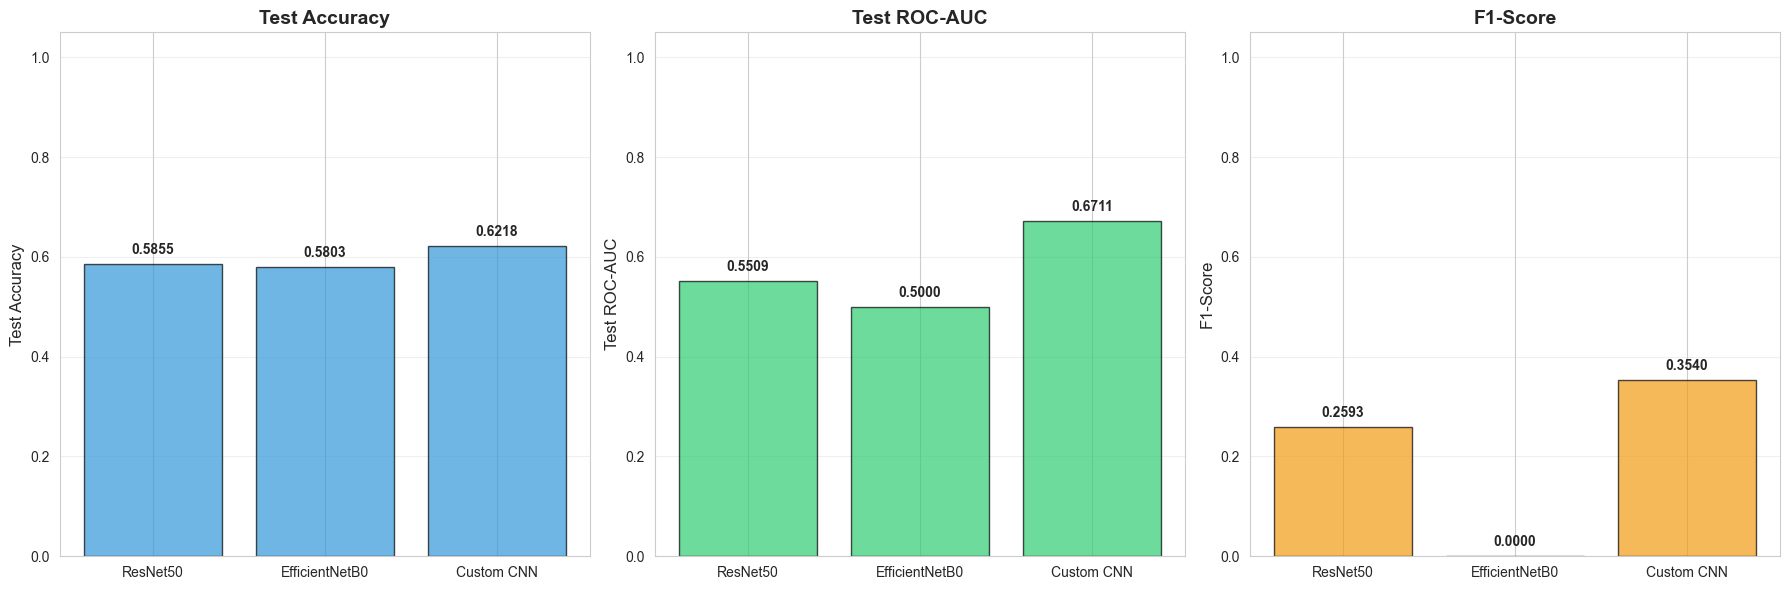

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/cnn_models_comparison.png

💾 Comparison saved


In [7]:
if DATA_AVAILABLE and 'all_results' in globals() and len(all_results) > 0:
    print_section_header("MODEL COMPARISON")
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame([{
        'Model': r['model_name'],
        'Test Loss': r['test_loss'],
        'Test Accuracy': r['test_accuracy'],
        'Test ROC-AUC': r['test_auc'],
        'F1-Score': r['f1_score']
    } for r in all_results])
    
    print("\n📊 Model Comparison:")
    print("="*80)
    print(comparison_df.to_string(index=False))
    print("="*80)
    
    # Save
    comparison_df.to_csv(RESULTS_DIR / 'cnn_models_comparison.csv', index=False)
    
    # Visualize comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    metrics = ['test_accuracy', 'test_auc', 'f1_score']
    titles = ['Test Accuracy', 'Test ROC-AUC', 'F1-Score']
    colors = ['#3498db', '#2ecc71', '#f39c12']
    
    for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
        values = [r[metric] for r in all_results]
        model_names = [r['model_name'] for r in all_results]
        
        axes[idx].bar(model_names, values, color=color, alpha=0.7, edgecolor='black')
        axes[idx].set_ylabel(title, fontsize=12)
        axes[idx].set_title(title, fontsize=14, fontweight='bold')
        axes[idx].set_ylim([0, 1.05])
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add value labels
        for i, v in enumerate(values):
            axes[idx].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    save_figure(fig, 'cnn_models_comparison', RESULTS_DIR)
    
    print("\n💾 Comparison saved")
else:
    print("⚠️ Skipping comparison - no evaluation results available")

## 9. Summary

In [8]:
print_section_header("SUMMARY")

print("""
✅ NOTEBOOK 09 COMPLETE

📋 WHAT WE'VE ACCOMPLISHED:

1. ✅ Data generators with augmentation
2. ✅ ResNet50 transfer learning model
3. ✅ EfficientNetB0 transfer learning model
4. ✅ Custom CNN from scratch
5. ✅ Training with callbacks (early stopping, checkpoint, LR scheduling)
6. ✅ Comprehensive evaluation on test set
7. ✅ Model comparison and visualization
8. ✅ Models saved to disk

🎯 KEY FINDINGS:

""")

if DATA_AVAILABLE and 'all_results' in globals() and len(all_results) > 0:
    # Show best model
    best_idx = np.argmax([r['test_auc'] for r in all_results])
    best_model = all_results[best_idx]
    
    print(f"🏆 BEST MODEL: {best_model['model_name']}")
    print(f"  Test Accuracy: {best_model['test_accuracy']:.4f}")
    print(f"  Test ROC-AUC:  {best_model['test_auc']:.4f}")
    print(f"  F1-Score:      {best_model['f1_score']:.4f}")
    
    print(f"""
💾 SAVED MODELS:
  - {DL_MODEL_DIR / 'resnet50_best.keras'}
  - {DL_MODEL_DIR / 'efficientnetb0_best.keras'}
  - {DL_MODEL_DIR / 'custom_cnn_best.keras'}

📈 TRAINING LOGS:
  - {RESULTS_DIR / 'resnet50_training_log.csv'}
  - {RESULTS_DIR / 'efficientnetb0_training_log.csv'}
  - {RESULTS_DIR / 'custom_cnn_training_log.csv'}

""")
elif DATA_AVAILABLE:
    print("⚠️ Data is available but no evaluation results were found in memory.")
    print("   Run the evaluation section to generate final metrics.")
else:
    print("⚠️ No data - models trained as demonstration only")

print("""
🔍 NEXT STEPS:

Notebook 10: Grad-CAM Explainability
- Visualize what CNNs are "looking at"
- Understand model decisions
- Clinical interpretation of predictions

""")
print("="*80)


                                    SUMMARY                                     


✅ NOTEBOOK 09 COMPLETE

📋 WHAT WE'VE ACCOMPLISHED:

1. ✅ Data generators with augmentation
2. ✅ ResNet50 transfer learning model
3. ✅ EfficientNetB0 transfer learning model
4. ✅ Custom CNN from scratch
5. ✅ Training with callbacks (early stopping, checkpoint, LR scheduling)
6. ✅ Comprehensive evaluation on test set
7. ✅ Model comparison and visualization
8. ✅ Models saved to disk

🎯 KEY FINDINGS:


🏆 BEST MODEL: Custom CNN
  Test Accuracy: 0.6218
  Test ROC-AUC:  0.6711
  F1-Score:      0.3540

💾 SAVED MODELS:
  - /Users/GiangNguyenHuy/Documents/breast-cancer-ai/models/deep_learning/resnet50_best.keras
  - /Users/GiangNguyenHuy/Documents/breast-cancer-ai/models/deep_learning/efficientnetb0_best.keras
  - /Users/GiangNguyenHuy/Documents/breast-cancer-ai/models/deep_learning/custom_cnn_best.keras

📈 TRAINING LOGS:
  - /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/resnet50_training_l